<div style="background-color: #f8f9fa; padding: 25px; border-radius: 10px; border-left: 6px solid #1a365d; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
    <h1 style="color: #1a365d; margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Data Science Final Project: Phase 2</h1>
    <h3 style="color: #4a5568; margin-top: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">University of Tehran - Spring 2026</h3>
    <hr style="border: 1px solid #e2e8f0;">
    <p style="font-size: 16px; color: #2d3748;">
        <b>Course:</b> Introduction to Data Science <br><br>
        <h5 style="color: #1a365d;"> Exploratory Data Analysis & Feature Fingerprinting</h5>
    </p>
</div>

<div class="alert alert-info" style="border-left: 4px solid #3182ce; background-color: #ebf8ff; color: #2b6cb0; margin-top: 20px;">
    <strong>💡 Project Overview:</strong> 
    This notebook contains the exploratory analysis for the MAESTRO dataset. To support our <b>Two-Stage Generative Architecture (Style Clustering + LSTM Generation)</b>, this pipeline evaluates global metadata distributions and physically parses raw <code>.midi</code> files to deduce mathematical stylistic fingerprints (note density, transition matrices, and pitch structures).
</div>

## Table of Contents
1. [Global Metadata Diagnostics & Preprocessing Evidence](#metadata)
2. [Feature Proof of Concept (Single File Analysis)](#extraction)
3. [Stylistic Contrast Visualization](#signatures)

<a id="metadata"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">1. Global Metadata Diagnostics & Preprocessing Evidence</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> We begin by evaluating the raw tabular metadata for missing values, operational outliers, and class imbalances. This section mathematically proves the necessity of our pipeline's cleaning rules.
</div>

##

### Initialization & Null Value Diagnostics

In [10]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pretty_midi

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 12, 'axes.titlesize': 14})

def load_dataset(path: str) -> pd.DataFrame:
    return pd.read_csv(path)

df = load_dataset('data/maestro-v3.0.0/maestro-v3.0.0.csv')

missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0]

if missing_data.empty:
    print("Zero missing values detected in raw metadata. Dataset is structurally complete.")
else:
    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing_data.index, y=missing_data.values, palette="Reds_r")
    plt.title("Missing Values by Column")
    plt.ylabel("Null Count")
    plt.show()

Zero missing values detected in raw metadata. Dataset is structurally complete.


### Global Distribution Diagnostics (Duration Outliers & Class Imbalance)

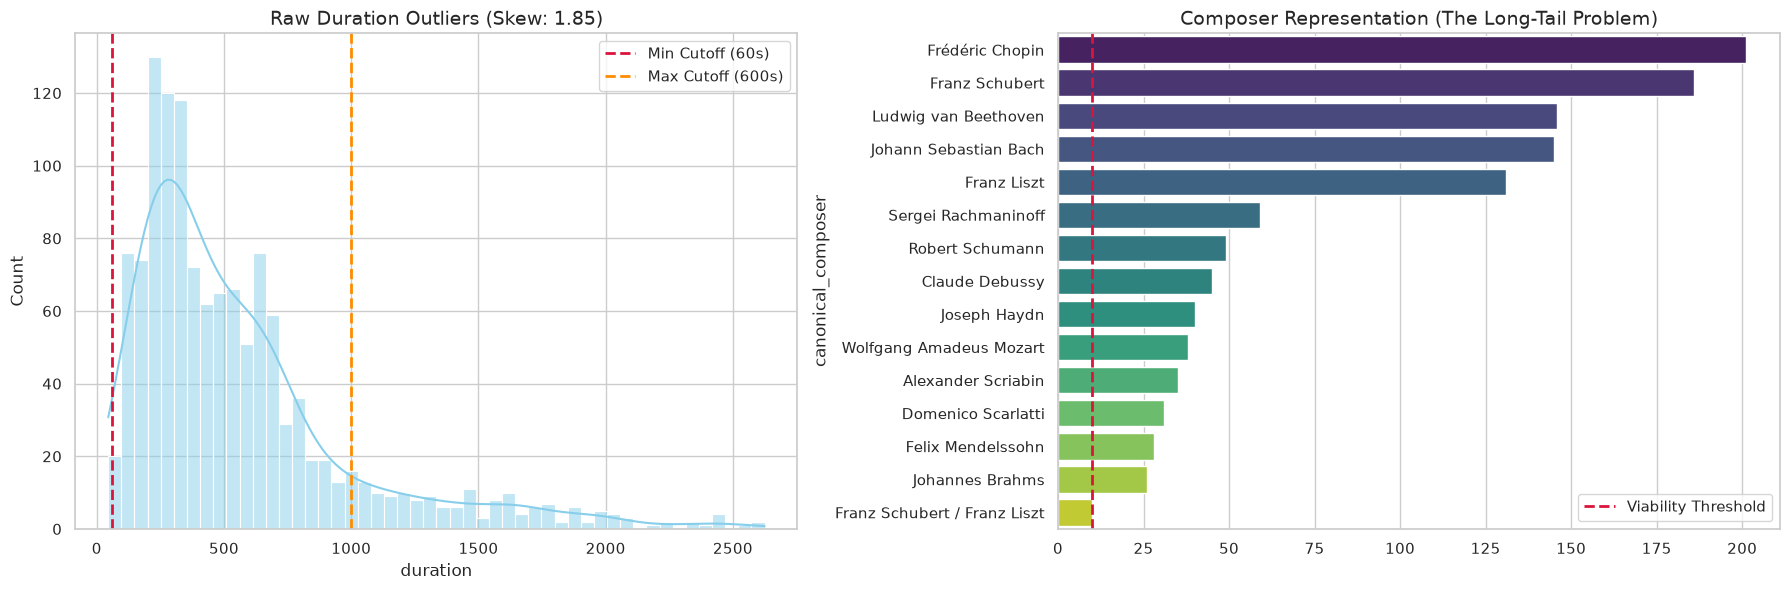

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(df['duration'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].axvline(60, color='crimson', linestyle='--', linewidth=2, label='Min Cutoff (60s)')
axes[0].axvline(1000, color='darkorange', linestyle='--', linewidth=2, label='Max Cutoff (600s)')
axes[0].set_title(f'Raw Duration Outliers (Skew: {df["duration"].skew():.2f})')
axes[0].legend()

top_composers = df['canonical_composer'].value_counts().head(15)
sns.barplot(x=top_composers.values, y=top_composers.index, ax=axes[1], palette='viridis')
axes[1].axvline(10, color='crimson', linestyle='--', linewidth=2, label='Viability Threshold')
axes[1].set_title('Composer Representation (The Long-Tail Problem)')
axes[1].legend()

plt.tight_layout()
plt.show()

### Stylistic Concentration: Composer vs. Recording Era (Leakage Proof)

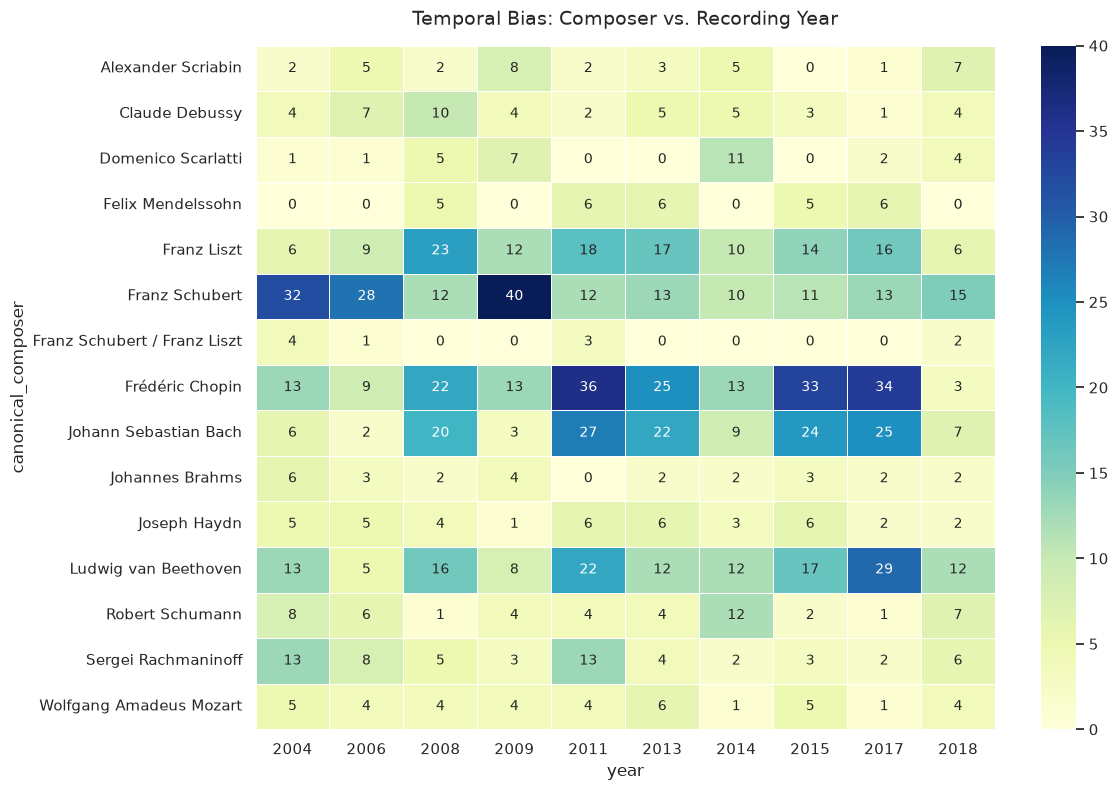

In [12]:
top_15_names = top_composers.index
filtered_df = df[df['canonical_composer'].isin(top_15_names)]
cross_tab = pd.crosstab(filtered_df['canonical_composer'], filtered_df['year'])

plt.figure(figsize=(12, 8))
sns.heatmap(cross_tab, annot=True, fmt="d", cmap="YlGnBu", cbar=True, linewidths=0.5)
plt.title("Temporal Bias: Composer vs. Recording Year", pad=15)
plt.tight_layout()
plt.show()

<a id="extraction"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">2. Feature Proof of Concept (Single File Analysis)</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> We do not perform batch feature extraction here (that is reserved for <code>feature_engineering.py</code>). Instead, we isolate exactly two distinct pieces (Baroque vs. Romantic) to mathematically prove that extracting Markov chains and pitch densities will create separable data for our Stage 1 clustering model.
</div>

##

### Isolating Contrast Samples

In [13]:
comp_A = "Johann Sebastian Bach"
comp_B = "Frédéric Chopin"

bach_row = df[df['canonical_composer'] == comp_A].iloc[0]
chopin_row = df[df['canonical_composer'] == comp_B].iloc[0]

base_dir = os.path.abspath('data/maestro-v3.0.0')
bach_path = os.path.join(base_dir, bach_row['midi_filename'].replace('/', os.sep))
chopin_path = os.path.join(base_dir, chopin_row['midi_filename'].replace('/', os.sep))

print(f"Loaded Sample A: {comp_A} - {bach_row['canonical_title']}")
print(f"Loaded Sample B: {comp_B} - {chopin_row['canonical_title']}")

Loaded Sample A: Johann Sebastian Bach - Chromatic Fantasy and Fugue in D Minor, BWV 903
Loaded Sample B: Frédéric Chopin - 12 Etudes, Op. 25


### Concept Extractor

In [14]:
def get_proof_of_concept_matrices(midi_path: str):
    pm = pretty_midi.PrettyMIDI(midi_path)
    notes = sorted([n for inst in pm.instruments for n in inst.notes], key=lambda x: x.start)
    
    pitches = np.array([n.pitch for n in notes])
    pitch_classes = pitches % 12
    pc_counts = np.bincount(pitch_classes, minlength=12)
    
    trans_matrix = np.zeros((12, 12))
    for i in range(len(pitch_classes)-1):
        trans_matrix[pitch_classes[i], pitch_classes[i+1]] += 1
        
    row_sums = trans_matrix.sum(axis=1, keepdims=True)
    prob_matrix = trans_matrix / np.where(row_sums == 0, 1, row_sums)
    
    return pc_counts, prob_matrix

bach_counts, bach_trans = get_proof_of_concept_matrices(bach_path)
chopin_counts, chopin_trans = get_proof_of_concept_matrices(chopin_path)

<a id="signatures"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">3. Stylistic Contrast Visualization</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> If the heatmaps of these two composers look visually distinct, it guarantees that our engineered features will successfully map into separable vector spaces during downstream clustering.
</div>

##

### Visualizing the Markov Chain Contrast

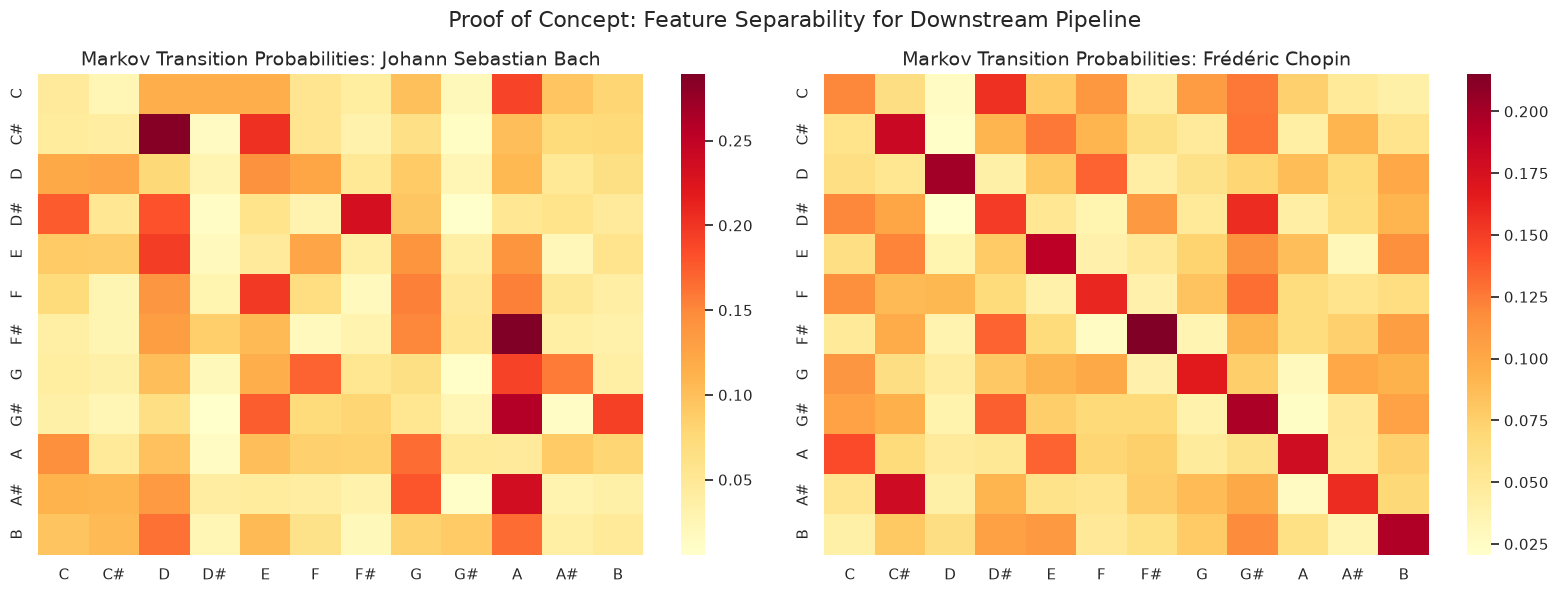

In [15]:
key_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(bach_trans, cmap='YlOrRd', xticklabels=key_names, yticklabels=key_names, ax=axes[0])
axes[0].set_title(f"Markov Transition Probabilities: {comp_A}")

sns.heatmap(chopin_trans, cmap='YlOrRd', xticklabels=key_names, yticklabels=key_names, ax=axes[1])
axes[1].set_title(f"Markov Transition Probabilities: {comp_B}")

plt.suptitle("Proof of Concept: Feature Separability for Downstream Pipeline", fontsize=16)
plt.tight_layout()
plt.show()

### Visualizing the Pitch Density Contrast

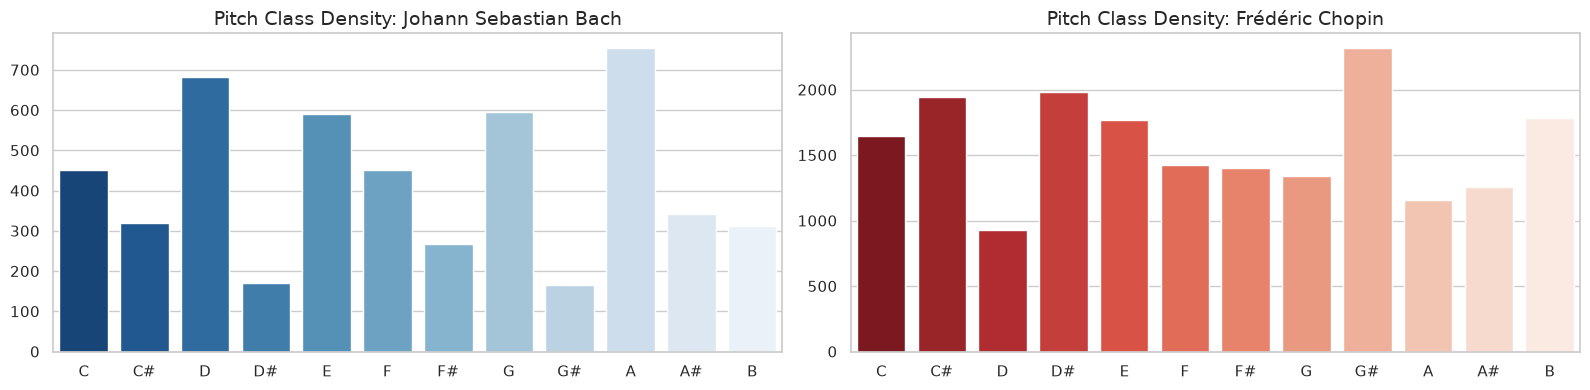

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.barplot(x=key_names, y=bach_counts, palette='Blues_r', ax=axes[0])
axes[0].set_title(f"Pitch Class Density: {comp_A}")

sns.barplot(x=key_names, y=chopin_counts, palette='Reds_r', ax=axes[1])
axes[1].set_title(f"Pitch Class Density: {comp_B}")

plt.tight_layout()
plt.show()

Running Pitch & Key EDA on 250 sampled MIDI files...
Key distribution plot saved to: /mnt/d/University/DS/CAs/UT-DataScience-Spring2026/Assignments/Final_Project/data/visualizations/key_distribution.png
Pitch class distribution plot saved to: /mnt/d/University/DS/CAs/UT-DataScience-Spring2026/Assignments/Final_Project/data/visualizations/pitch_class_distribution.png


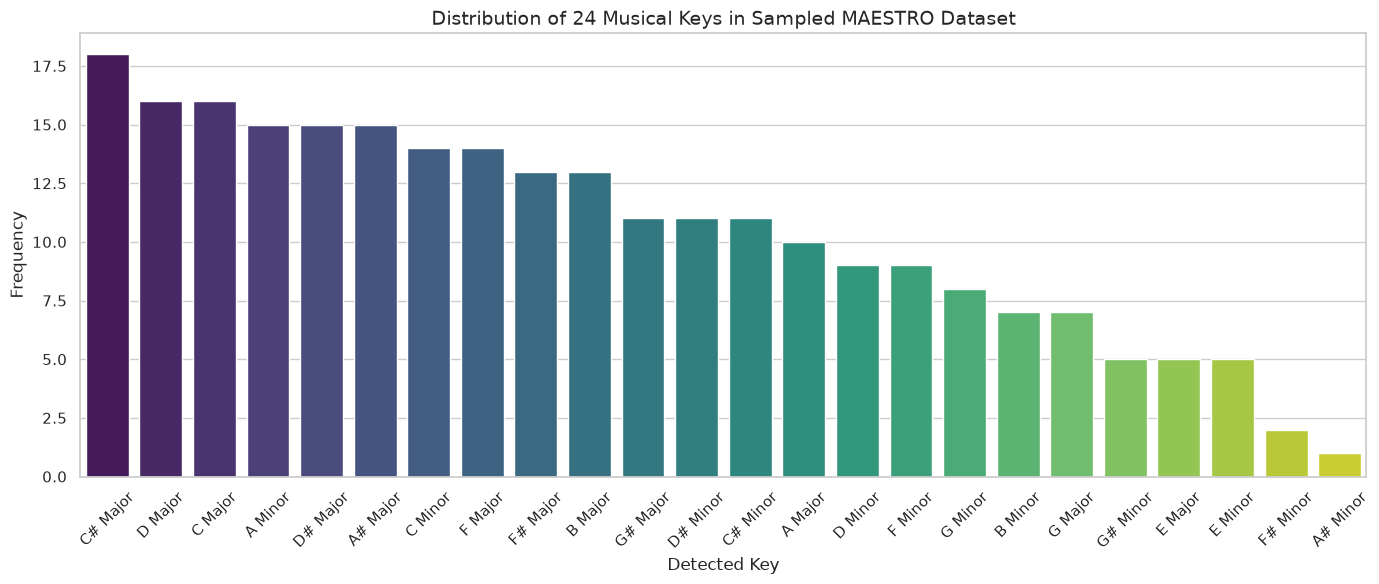

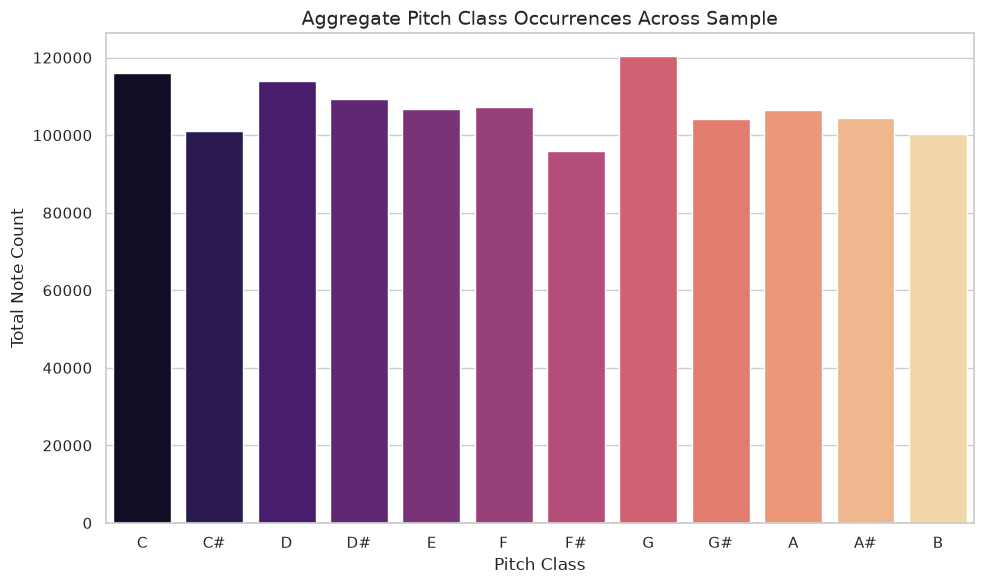

In [18]:
import os
import numpy as np
import pandas as pd
import pretty_midi
import matplotlib.pyplot as plt
import seaborn as sns

# Krumhansl-Schmuckler pitch profiles for all 24 keys
MAJOR_PROFILE = np.array([6.35, 2.23, 3.48, 2.33, 4.38, 4.09, 2.52, 5.19, 2.39, 3.66, 2.29, 2.88])
MINOR_PROFILE = np.array([6.33, 2.68, 3.52, 5.38, 2.60, 3.53, 2.54, 4.75, 3.98, 2.69, 3.34, 3.17])
PITCH_CLASSES = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

def detect_key_and_pitches(midi_path: str):
    """Parses a single MIDI file to find its key and raw pitch class distribution."""
    try:
        pm = pretty_midi.PrettyMIDI(midi_path)
        notes = [n for inst in pm.instruments for n in inst.notes]
        if not notes:
            return None, None
            
        pitches = [n.pitch for n in notes]
        pc_counts = np.bincount([p % 12 for p in pitches], minlength=12)
        
        if np.std(pc_counts) == 0:
            return None, pc_counts
            
        maj_corr = [np.corrcoef(pc_counts, np.roll(MAJOR_PROFILE, i))[0, 1] for i in range(12)]
        min_corr = [np.corrcoef(pc_counts, np.roll(MINOR_PROFILE, i))[0, 1] for i in range(12)]
        
        best_maj_key = np.argmax(maj_corr)
        best_min_key = np.argmax(min_corr)
        
        # Compare highest correlation to determine Major vs Minor
        if maj_corr[best_maj_key] >= min_corr[best_min_key]:
            key = f"{PITCH_CLASSES[best_maj_key]} Major"
        else:
            key = f"{PITCH_CLASSES[best_min_key]} Minor"
            
        return key, pc_counts
    except Exception:
        return None, None

def run_eda(sample_size: int = 250) -> None:
    """Runs Exploratory Data Analysis on a sample of the dataset to visualize keys."""
    # Fix for Jupyter Notebook environments where __file__ is not defined
    try:
        base_dir = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
    except NameError:
        # Fallback for Jupyter/IPython
        current_dir = os.getcwd()
        # If the notebook is inside a 'scripts' folder, go up one level to the project root
        if os.path.basename(current_dir) == 'scripts':
            base_dir = os.path.dirname(current_dir)
        else:
            base_dir = current_dir

    data_dir = os.path.join(base_dir, 'data', 'maestro-v3.0.0')
    input_pkl = os.path.join(base_dir, 'data', 'dataframes', 'preprocessed_data.pkl')
    output_dir = os.path.join(base_dir, 'data', 'visualizations')
    os.makedirs(output_dir, exist_ok=True)
    
    if not os.path.exists(input_pkl):
        raise FileNotFoundError(f"Input file missing: {input_pkl}\nExpected path: {input_pkl}")
        
    df = pd.read_pickle(input_pkl)
    
    # Process a random sample to save execution time
    df_sample = df.sample(n=min(sample_size, len(df)), random_state=42)
    print(f"Running Pitch & Key EDA on {len(df_sample)} sampled MIDI files...")
    
    keys_detected = []
    total_pitch_classes = np.zeros(12)
    
    for _, row in df_sample.iterrows():
        midi_path = os.path.join(data_dir, row['midi_filename'].replace('/', os.sep))
        
        if os.path.exists(midi_path):
            key, pc_counts = detect_key_and_pitches(midi_path)
            if key:
                keys_detected.append(key)
            if pc_counts is not None:
                total_pitch_classes += pc_counts
                
    generate_plots(keys_detected, total_pitch_classes, output_dir)

def generate_plots(keys_detected: list, total_pitch_classes: np.ndarray, output_dir: str) -> None:
    """Generates and saves the EDA visualizations."""
    sns.set_theme(style="whitegrid")
    
    # 1. Plotting Key Distribution
    plt.figure(figsize=(14, 6))
    key_series = pd.Series(keys_detected).value_counts()
    
    sns.barplot(
        x=key_series.index, 
        y=key_series.values, 
        hue=key_series.index, 
        palette="viridis", 
        legend=False
    )
    plt.title("Distribution of 24 Musical Keys in Sampled MAESTRO Dataset", fontsize=14)
    plt.xlabel("Detected Key", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    key_plot_path = os.path.join(output_dir, 'key_distribution.png')
    plt.savefig(key_plot_path)
    print(f"Key distribution plot saved to: {key_plot_path}")
    
    # 2. Plotting Overall Pitch Class Distribution
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=PITCH_CLASSES, 
        y=total_pitch_classes, 
        hue=PITCH_CLASSES, 
        palette="magma", 
        legend=False
    )
    plt.title("Aggregate Pitch Class Occurrences Across Sample", fontsize=14)
    plt.xlabel("Pitch Class", fontsize=12)
    plt.ylabel("Total Note Count", fontsize=12)
    plt.tight_layout()
    
    pitch_plot_path = os.path.join(output_dir, 'pitch_class_distribution.png')
    plt.savefig(pitch_plot_path)
    print(f"Pitch class distribution plot saved to: {pitch_plot_path}")

if __name__ == "__main__":
    run_eda()